# How SVM Kernels Change Classification on the Banknote Authentication Dataset

This notebook is designed to support a tutorial on **Support Vector Machines (SVMs)** using a single real dataset: the **UCI Banknote Authentication** dataset.



## Dataset
The dataset contains four real-valued features extracted from wavelet-transformed images of banknotes and one binary class label.
- UCI dataset page: https://archive.ics.uci.edu/ml/datasets/banknote%2Bauthentication



GitHub Repository: https://github.com/rt25aaz/Machine-Learning-Tutorial-by-Talha.git

In [1]:
# Mount Google Drive when running in Colab.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Import libraries and define project paths.
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

RANDOM_STATE = 42

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
DATA_PATH = PROJECT_ROOT / "data" / "banknote_authentication.csv"
FIG_DIR = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data path exists:", DATA_PATH.exists())

Project root: /content
Data path exists: True


## 1. Load and inspect the dataset

In [5]:
# Download the dataset once and save it locally as a CSV.
import requests
from io import StringIO

# Ensure the data directory exists
DATA_DIR = DATA_PATH.parent
if not DATA_DIR.exists():
    DATA_DIR.mkdir(parents=True, exist_ok=True)

# URL for the raw data from UCI Machine Learning Repository
UCI_RAW_DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt"

# Column names based on the notebook's usage
column_names = ['variance', 'skewness', 'curtosis', 'entropy', 'class']

# Download the raw data and save it as the expected CSV with headers
# This step ensures the 'banknote_authentication.csv' file exists with correct headers
# before pd.read_csv(DATA_PATH) is called.
if not DATA_PATH.exists():
    print(f"Downloading data from {UCI_RAW_DATA_URL} and preparing {DATA_PATH}...")
    try:
        response = requests.get(UCI_RAW_DATA_URL)
        response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)

        # Read the content into a DataFrame, assign column names, and save as CSV
        s = StringIO(response.text)
        df_temp = pd.read_csv(s, header=None, names=column_names)
        df_temp.to_csv(DATA_PATH, index=False)
        print(f"Data successfully prepared and saved to {DATA_PATH}.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading or processing data: {e}")
        # If there's an error, prevent the original read_csv from failing by re-raising
        raise FileNotFoundError(f"Failed to prepare {DATA_PATH} for reading.")


df = pd.read_csv(DATA_PATH)
df.head()

,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [6]:
# Quick check of shape, columns, missing values, and class balance.
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nMissing values per column:")
print(df.isna().sum())
print("\nClass balance:")
print(df["class"].value_counts().sort_index())

Shape: (1372, 5)

Column names:
['variance', 'skewness', 'curtosis', 'entropy', 'class']

Missing values per column:
variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64

Class balance:
class
0    762
1    610
Name: count, dtype: int64


In [7]:
# Summary statistics for the numeric features.
summary = df.describe().T
summary

,count,mean,std,min,25%,50%,75%,max
variance,1372.0,0.433735,2.842763,-7.0421,-1.773000,0.49618,2.821475,6.8248
skewness,1372.0,1.922353,5.869047,-13.7731,-1.708200,2.31965,6.814625,12.9516
curtosis,1372.0,1.397627,4.310030,-5.2861,-1.574975,0.61663,3.179250,17.9274
entropy,1372.0,-1.191657,2.101013,-8.5482,-2.413450,-0.58665,0.394810,2.4495
class,1372.0,0.444606,0.497103,0.0000,0.000000,0.00000,1.000000,1.0000


### Quick interpretation

This is a clean binary-classification dataset:
- **1372 rows**
- **4 numeric input features**
- **1 binary target column**
- **no missing values**



In [8]:
# Split features/labels into stratified train and test sets.
X = df.drop(columns="class")
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (1029, 4)
Test set: (343, 4)


## 2. Why scaling matters for SVMs

SVMs depend on distances and margins in feature space, so it is good practice to **standardize** numeric features before training.


In [9]:
# Tune linear, polynomial, and RBF SVMs with cross-validation.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search_spaces = {
    "linear": {
        "svc__kernel": ["linear"],
        "svc__C": [0.01, 0.1, 1, 10, 100],
    },
    "poly": {
        "svc__kernel": ["poly"],
        "svc__C": [0.1, 1, 10],
        "svc__degree": [2, 3],
        "svc__gamma": ["scale", 0.1],
        "svc__coef0": [0, 1],
    },
    "rbf": {
        "svc__kernel": ["rbf"],
        "svc__C": [0.1, 1, 10, 100],
        "svc__gamma": ["scale", 0.01, 0.1, 1],
    },
}

results = []
best_estimators = {}

for kernel_name, param_grid in search_spaces.items():
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(random_state=RANDOM_STATE)),
    ])

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring="accuracy",
        cv=cv,
        n_jobs=1,
        refit=True,
    )
    grid.fit(X_train, y_train)

    best_estimators[kernel_name] = grid.best_estimator_
    y_pred = grid.predict(X_test)
    y_score = grid.decision_function(X_test)

    results.append({
        "kernel": kernel_name,
        "best_params": grid.best_params_,
        "cv_accuracy": grid.best_score_,
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_f1": f1_score(y_test, y_pred),
        "test_roc_auc": roc_auc_score(y_test, y_score),
        "n_support_vectors": int(grid.best_estimator_["svc"].n_support_.sum()),
    })

results_df = pd.DataFrame(results).sort_values(by="test_accuracy", ascending=False).reset_index(drop=True)
results_df

,kernel,best_params,cv_accuracy,test_accuracy,test_f1,test_roc_auc,n_support_vectors
0,poly,"{'svc__C': 1, 'svc__coef0': 1, 'svc__degree': ...",1.000000,1.000000,1.000000,1.000000,38
1,rbf,"{'svc__C': 10, 'svc__gamma': 'scale', 'svc__ke...",1.000000,1.000000,1.000000,1.000000,37
2,linear,"{'svc__C': 10, 'svc__kernel': 'linear'}",0.993199,0.985423,0.983819,0.999828,35


## 3. Kernel comparison on the full 4-feature dataset

The table below is the main quantitative comparison for the tutorial. It compares the best version of each kernel after cross-validated tuning on the training set.

In [10]:
# Round results for easier reading in the notebook.
results_rounded = results_df.copy()
for col in ["cv_accuracy", "test_accuracy", "test_f1", "test_roc_auc"]:
    results_rounded[col] = results_rounded[col].round(4)
results_rounded

,kernel,best_params,cv_accuracy,test_accuracy,test_f1,test_roc_auc,n_support_vectors
0,poly,"{'svc__C': 1, 'svc__coef0': 1, 'svc__degree': ...",1.0000,1.0000,1.0000,1.0000,38
1,rbf,"{'svc__C': 10, 'svc__gamma': 'scale', 'svc__ke...",1.0000,1.0000,1.0000,1.0000,37
2,linear,"{'svc__C': 10, 'svc__kernel': 'linear'}",0.9932,0.9854,0.9838,0.9998,35


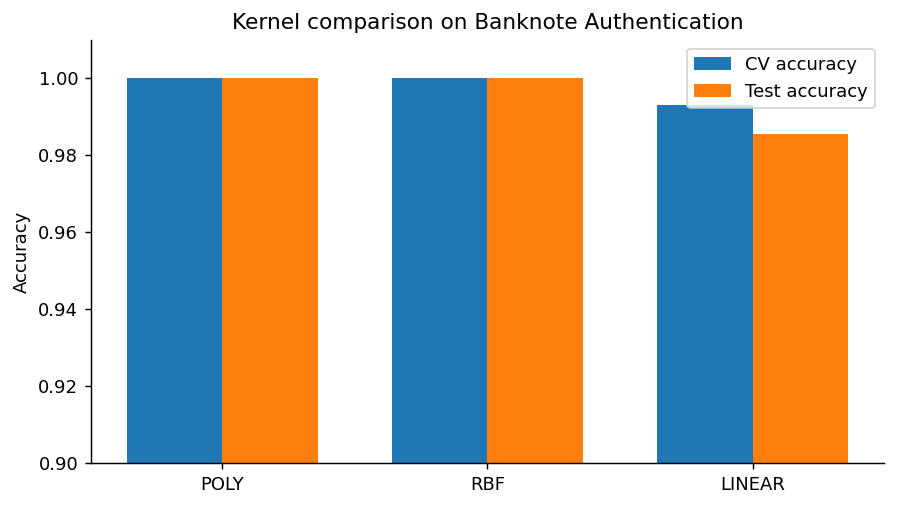

In [11]:
# Plot cross-validation and test accuracy for each kernel.
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(results_df))
width = 0.36

ax.bar(x - width/2, results_df["cv_accuracy"], width=width, label="CV accuracy")
ax.bar(x + width/2, results_df["test_accuracy"], width=width, label="Test accuracy")

ax.set_xticks(x)
ax.set_xticklabels(results_df["kernel"].str.upper())
ax.set_ylim(0.9, 1.01)
ax.set_ylabel("Accuracy")
ax.set_title("Kernel comparison on Banknote Authentication")
ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "kernel_accuracy_comparison.png", bbox_inches="tight")
plt.show()

### Interpretation

This figure helps communicate a simple teaching point:
- the **linear kernel** is the simplest baseline,
- the **polynomial kernel** can model more complex boundaries,
- and the **RBF kernel** is usually the most flexible.



## 4. Classification reports and confusion matrices

In [12]:
# Print a classification report for each best model.
for kernel_name in ["linear", "poly", "rbf"]:
    model = best_estimators[kernel_name]
    preds = model.predict(X_test)

    print(f"\n{'='*70}")
    print(f"{kernel_name.upper()} kernel")
    print(model)
    print("\nClassification report:")
    print(classification_report(y_test, preds, digits=4))


LINEAR kernel
Pipeline(steps=[('scaler', StandardScaler()),
                ('svc', SVC(C=10, kernel='linear', random_state=42))])

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.9738    0.9867       191
           1     0.9682    1.0000    0.9838       152

    accuracy                         0.9854       343
   macro avg     0.9841    0.9869    0.9853       343
weighted avg     0.9859    0.9854    0.9854       343


POLY kernel
Pipeline(steps=[('scaler', StandardScaler()),
                ('svc', SVC(C=1, coef0=1, kernel='poly', random_state=42))])

Classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       191
           1     1.0000    1.0000    1.0000       152

    accuracy                         1.0000       343
   macro avg     1.0000    1.0000    1.0000       343
weighted avg     1.0000    1.0000    1.0000       343


RBF kernel
Pipeline(steps=[('

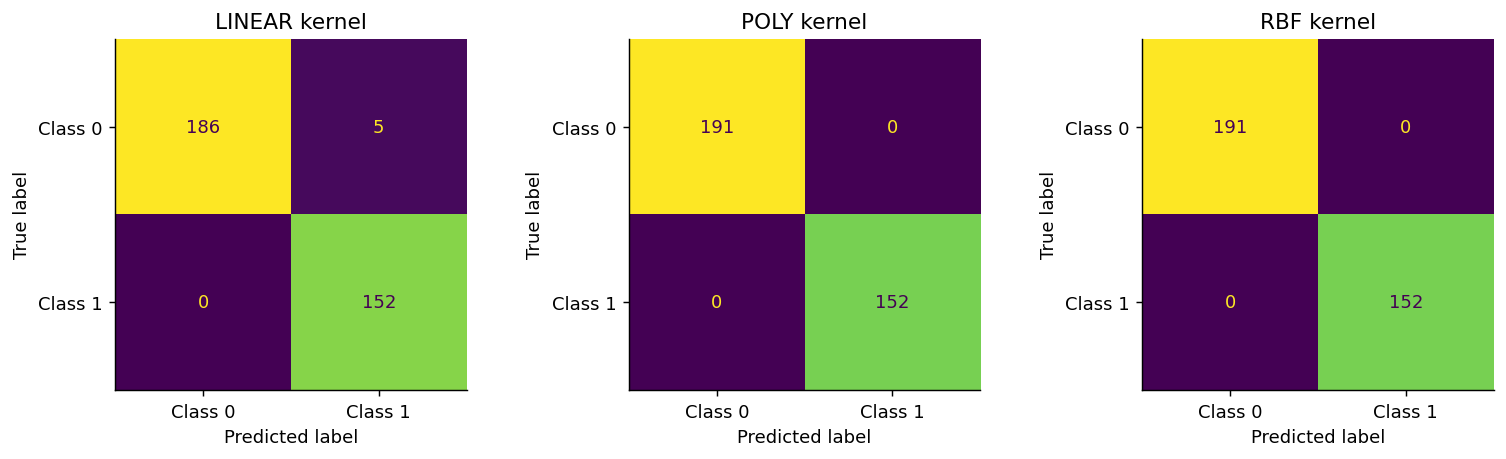

In [13]:
# Show confusion matrices to see where errors occur.
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))

for ax, kernel_name in zip(axes, ["linear", "poly", "rbf"]):
    model = best_estimators[kernel_name]
    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        display_labels=["Class 0", "Class 1"],
        colorbar=False,
        ax=ax,
    )
    ax.set_title(f"{kernel_name.upper()} kernel")

plt.tight_layout()
plt.savefig(FIG_DIR / "confusion_matrices.png", bbox_inches="tight")
plt.show()

Confusion matrices are useful in the tutorial because they move the discussion beyond a single accuracy number and show **where** mistakes occur.

## 5. Visualising decision boundaries on the same dataset

The models above were trained on all four original features.
However, a 4D decision boundary cannot be plotted directly. we project the same dataset into **two principal components (PCA)**.



In [14]:
# Reduce the data to 2D with PCA for visualisation only.
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca.fit_transform(X)

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_2d, y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE
)

explained = pca.explained_variance_ratio_
print("Explained variance ratio:", explained)
print("Total explained variance in 2D:", round(float(explained.sum()), 4))

Explained variance ratio: [0.76132409 0.1419049 ]
Total explained variance in 2D: 0.9032


In [15]:
# Refit comparable models in PCA space to draw boundaries.
viz_models = {}

for kernel_name, fitted_model in best_estimators.items():
    best_params = fitted_model.get_params()
    viz_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(
            kernel=best_params["svc__kernel"],
            C=best_params["svc__C"],
            degree=best_params.get("svc__degree", 3),
            gamma=best_params.get("svc__gamma", "scale"),
            coef0=best_params.get("svc__coef0", 0),
            random_state=RANDOM_STATE,
        )),
    ])
    viz_pipe.fit(X2_train, y2_train)
    viz_models[kernel_name] = viz_pipe

In [16]:
# Helper functions for plotting classes, boundaries, and support vectors.
def plot_points(ax, X_plot, y_plot, title):
    markers = {0: "o", 1: "^"}
    labels = {0: "Class 0", 1: "Class 1"}
    for cls in sorted(np.unique(y_plot)):
        mask = (y_plot == cls)
        ax.scatter(
            X_plot[mask, 0],
            X_plot[mask, 1],
            s=28,
            marker=markers[cls],
            label=labels[cls],
            edgecolor="black",
            linewidth=0.4,
            alpha=0.85,
        )
    ax.set_title(title)
    ax.set_xlabel("Principal component 1")
    ax.set_ylabel("Principal component 2")


def decision_plot(ax, model, X_plot, y_plot, title):
    DecisionBoundaryDisplay.from_estimator(
        model,
        X_plot,
        response_method="predict",
        alpha=0.18,
        ax=ax,
        xlabel="Principal component 1",
        ylabel="Principal component 2",
        grid_resolution=300,
    )
    plot_points(ax, X_plot, y_plot, title)

    svc = model.named_steps["svc"]
    support_idx = svc.support_
    ax.scatter(
        X_plot[support_idx, 0],
        X_plot[support_idx, 1],
        s=85,
        facecolors="none",
        edgecolors="black",
        linewidth=1.0,
        label="Support vectors",
    )

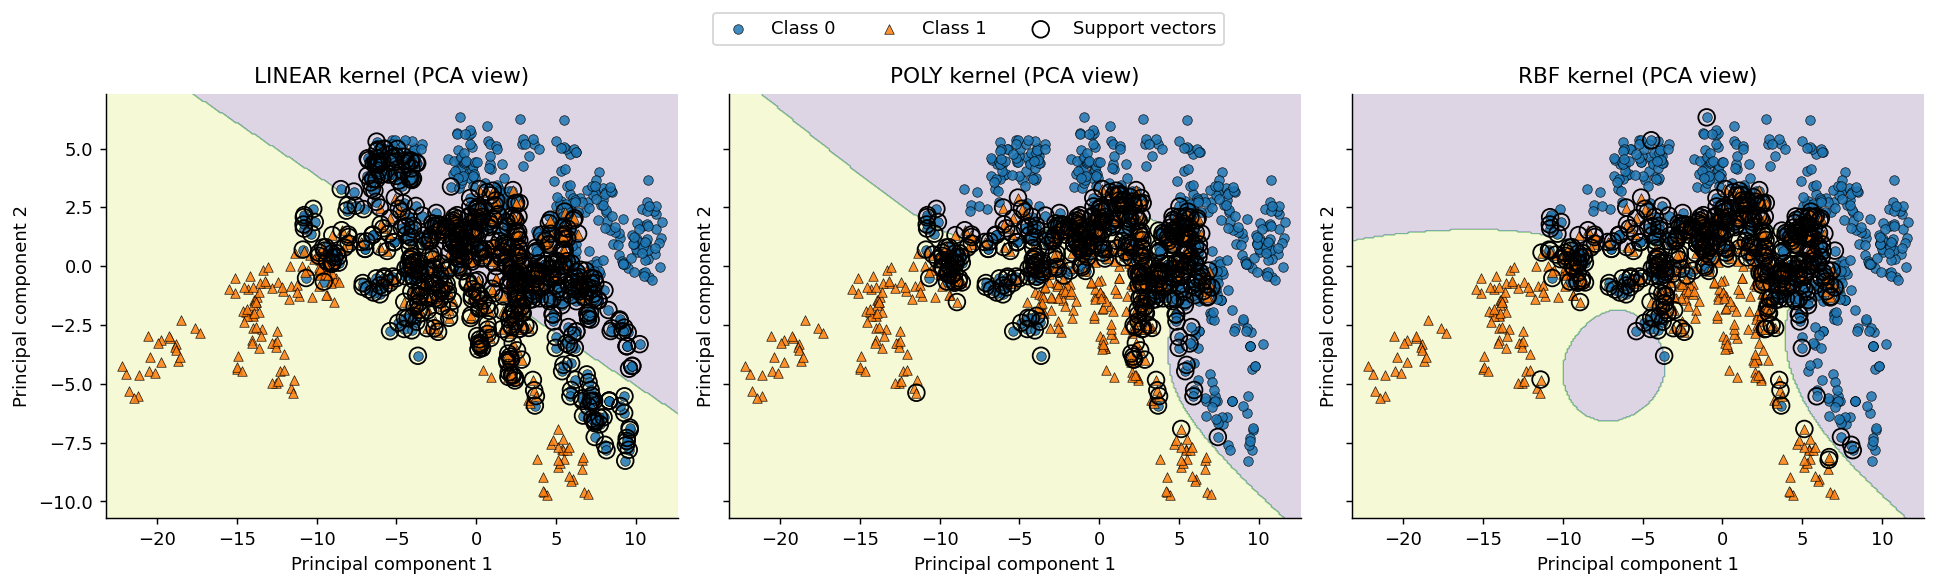

In [17]:
# Compare the learned boundaries of the three kernels in PCA space.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharex=True, sharey=True)

for ax, kernel_name in zip(axes, ["linear", "poly", "rbf"]):
    decision_plot(
        ax,
        viz_models[kernel_name],
        X2_train,
        y2_train.to_numpy(),
        f"{kernel_name.upper()} kernel (PCA view)"
    )

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.08))
plt.tight_layout()
plt.savefig(FIG_DIR / "decision_boundaries_pca.png", bbox_inches="tight")
plt.show()

### Interpretation

This is one of the most important figures in the notebook:
- **Linear SVM** creates a straight decision boundary.
- **Polynomial SVM** bends the boundary using polynomial interactions.
- **RBF SVM** can create the most flexible boundary and usually adapts best to local structure.

The hollow markers show **support vectors**, the points that define the margin and therefore have the greatest influence on the final boundary.

## 6. Deep dive: How C and gamma change an RBF SVM


### Key ideas
- **C** controls the penalty for misclassification.
  - small `C` -> wider, softer margin
  - large `C` -> narrower, stricter fit to the training data
- **gamma** controls how local the RBF influence is.
  - small `gamma` -> smoother, broader influence
  - large `gamma` -> more local, more irregular decision boundary

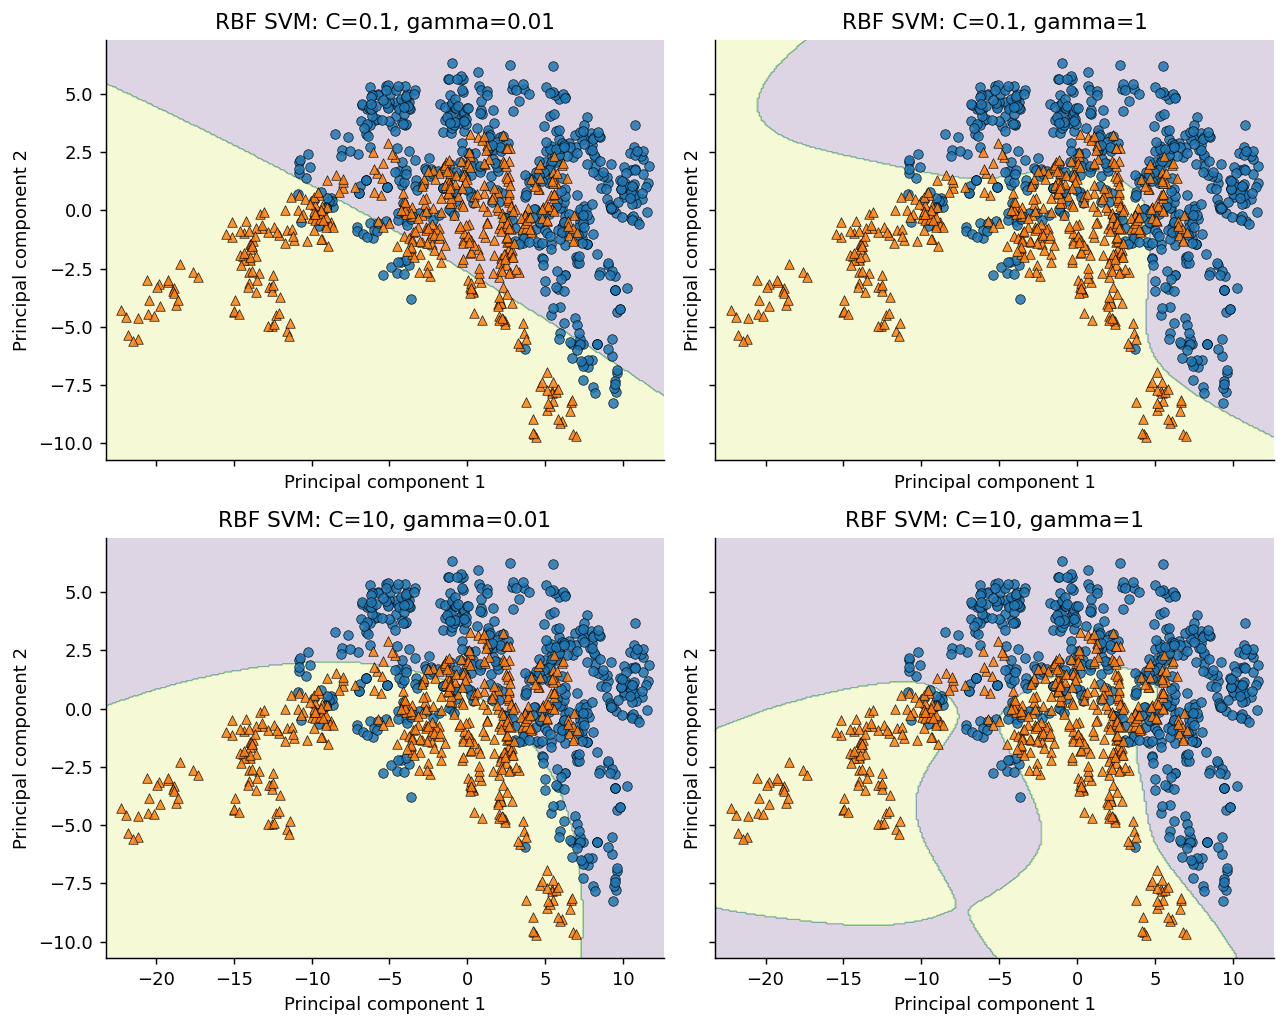

In [18]:
# Show how changing C and gamma alters the RBF boundary.
rbf_grid = [
    {"C": 0.1, "gamma": 0.01},
    {"C": 0.1, "gamma": 1},
    {"C": 10, "gamma": 0.01},
    {"C": 10, "gamma": 1},
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)

for ax, params in zip(axes.ravel(), rbf_grid):
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="rbf", C=params["C"], gamma=params["gamma"], random_state=RANDOM_STATE)),
    ])
    model.fit(X2_train, y2_train)

    DecisionBoundaryDisplay.from_estimator(
        model,
        X2_train,
        response_method="predict",
        alpha=0.18,
        ax=ax,
        xlabel="Principal component 1",
        ylabel="Principal component 2",
        grid_resolution=300,
    )

    plot_points(ax, X2_train, y2_train.to_numpy(), f"RBF SVM: C={params['C']}, gamma={params['gamma']}")

plt.tight_layout()
plt.savefig(FIG_DIR / "rbf_c_gamma_effects.png", bbox_inches="tight")
plt.show()

### Interpretation


It shows **why tuning matters**:
- low `C` and low `gamma` usually produce a smoother, less flexible boundary,
- high `gamma` makes the boundary more sensitive to local points,
- high `C` encourages the model to avoid training errors more aggressively,
- combining high `C` with high `gamma` can make the boundary more complex and increase overfitting risk.